# Constants

In [ ]:
import os
weeks_to_count = 6
session_window_hours = 2
output_folder = "processed3"
os.makedirs(output_folder, exist_ok=True)

# Filter unique students for 1125 (k67) & 1124 (k66)

In [ ]:
import pandas as pd

# 1. Load the original dataset
df = pd.read_csv('user_course_metadata.csv', encoding='utf-8')

# 2. Filter users whose email starts with '1124' or '1125'
# Using .copy() prevents the "SettingWithCopyWarning" when we add a new column
filtered_df = df[df['email'].astype(str).str.startswith(('1124', '1125'))].copy()

# 3. Create the 'msv' column by taking the part of the email before '@'
filtered_df['msv'] = filtered_df['email'].str.split('@').str[0]

# 4. Select only the desired columns: user_id, full_name, and msv
final_df = filtered_df[['user_id', 'full_name', 'msv']]

# 5. Drop duplicates to ensure there are no repeated rows
final_df = final_df.drop_duplicates()

# 6. Save the unique list to a new CSV file
output_file = f'{output_folder}/unique_users_msv_1124_1125.csv'
final_df.to_csv(output_file, index=False, encoding='utf-8')

# Optional: Print out a summary
print(f"Total unique users found: {len(final_df)}")
print(final_df.head())

Total unique users found: 454
    user_id              full_name       msv
16      197  An Nguyễn Hoàng Thiên  11247118
17      198            Anh Bùi Duy  11247121
18      199           Anh Đinh Vân  11247123
19      200         Anh Dương Minh  11247125
20      201        Anh Nguyễn Hồng  11247130


# Find the slop over 6 weeks before test days


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the data files
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')

# 2. Ensure the timestamp column is in a proper datetime format
clicks_data['click_time'] = pd.to_datetime(clicks_data['local_datetime'])

# 3. Define the specific target 8-week windows for each group
end_date_1124 = pd.to_datetime('2025-12-13')
start_date_1124 = end_date_1124 - pd.Timedelta(weeks=weeks_to_count)

end_date_1125 = pd.to_datetime('2026-01-16')
start_date_1125 = end_date_1125 - pd.Timedelta(weeks=weeks_to_count)

# 4. Merge the unique users with their full click history
merged_data = pd.merge(unique_users, clicks_data, left_on='user_id', right_on='userid', how='inner')

# 5. Filter for 1124 students within their specific 8-week window
mask_1124 = (
    merged_data['msv'].astype(str).str.startswith('1124') &
    (merged_data['click_time'] >= start_date_1124) &
    (merged_data['click_time'] < end_date_1124)
)
data_1124 = merged_data[mask_1124].copy()
# Calculate which week (0 to 7) the click happened in
data_1124['week_number'] = (data_1124['click_time'] - start_date_1124).dt.days // 7

# 6. Filter for 1125 students within their specific 8-week window
mask_1125 = (
    merged_data['msv'].astype(str).str.startswith('1125') &
    (merged_data['click_time'] >= start_date_1125) &
    (merged_data['click_time'] < end_date_1125)
)
data_1125 = merged_data[mask_1125].copy()
# Calculate which week (0 to 7) the click happened in
data_1125['week_number'] = (data_1125['click_time'] - start_date_1125).dt.days // 7

# 7. Combine the valid, filtered data from both groups back together
valid_clicks = pd.concat([data_1124, data_1125])

# 8. Group by user and week to get the raw click counts per week
weekly_counts = valid_clicks.groupby(['user_id', 'full_name', 'msv', 'week_number']).size().reset_index(name='click_count')

# --- CRITICAL ENHANCEMENT: Filling Missing Weeks with Zeros ---
# If a student didn't click at all in Week 3, the row is missing. We MUST insert a '0'
# so the linear regression knows the interaction dropped, rather than just ignoring that week.

# Create a template of all users and all possible weeks (0 through 7)
users_list = unique_users[['user_id', 'full_name', 'msv']].drop_duplicates()
weeks = pd.DataFrame({'week_number': range(weeks_to_count)})
all_combinations = users_list.merge(weeks, how='cross')

# Merge actual counts with the template, filling the missing gaps with 0
full_weekly_data = pd.merge(all_combinations, weekly_counts, on=['user_id', 'full_name', 'msv', 'week_number'], how='left')
full_weekly_data['click_count'] = full_weekly_data['click_count'].fillna(0)

# 9. Define the function to calculate the slope using linear regression
def calculate_slope(group):
    x = group['week_number'].values
    y = group['click_count'].values

    # We now guarantee exactly 8 data points (weeks 0-7) for every user
    # np.polyfit(x, y, 1) calculates a 1st degree polynomial (y = mx + b)
    slope, _ = np.polyfit(x, y, 1)
    return slope

# 10. Apply the slope function to each individual user
user_slopes = full_weekly_data.groupby(['user_id', 'full_name', 'msv']).apply(calculate_slope).reset_index(name='slope_clicks_over_time')

# Sort by slope (most negative slopes first = highest risk of dropping out)
user_slopes = user_slopes.sort_values(by='slope_clicks_over_time')

# 11. Save the final results to a new CSV file
output_file = f'{output_folder}/historical_engagement_slopes.csv'
user_slopes.to_csv(output_file, index=False, encoding='utf-8')

# Optional: Print out a quick summary
print(f"Calculated slopes for {len(user_slopes)} users.")
print(user_slopes.head())

Calculated slopes for 454 users.
     user_id         full_name       msv  slope_clicks_over_time
321     1224      Quân Tạ Minh  11257141              -64.714286
424     1327        Văn Lê Duy  11258886              -37.857143
422     1325      Thái Lại Duy  11257497              -35.828571
415     1318  Minh Nguyễn Tuấn  11255524              -32.142857
403     1306    Dương Lưu Thái  11252245              -30.828571


/tmp/ipykernel_45137/9231725.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_slopes = full_weekly_data.groupby(['user_id', 'full_name', 'msv']).apply(calculate_slope).reset_index(name='slope_clicks_over_time')


# Plot the graph for sloping

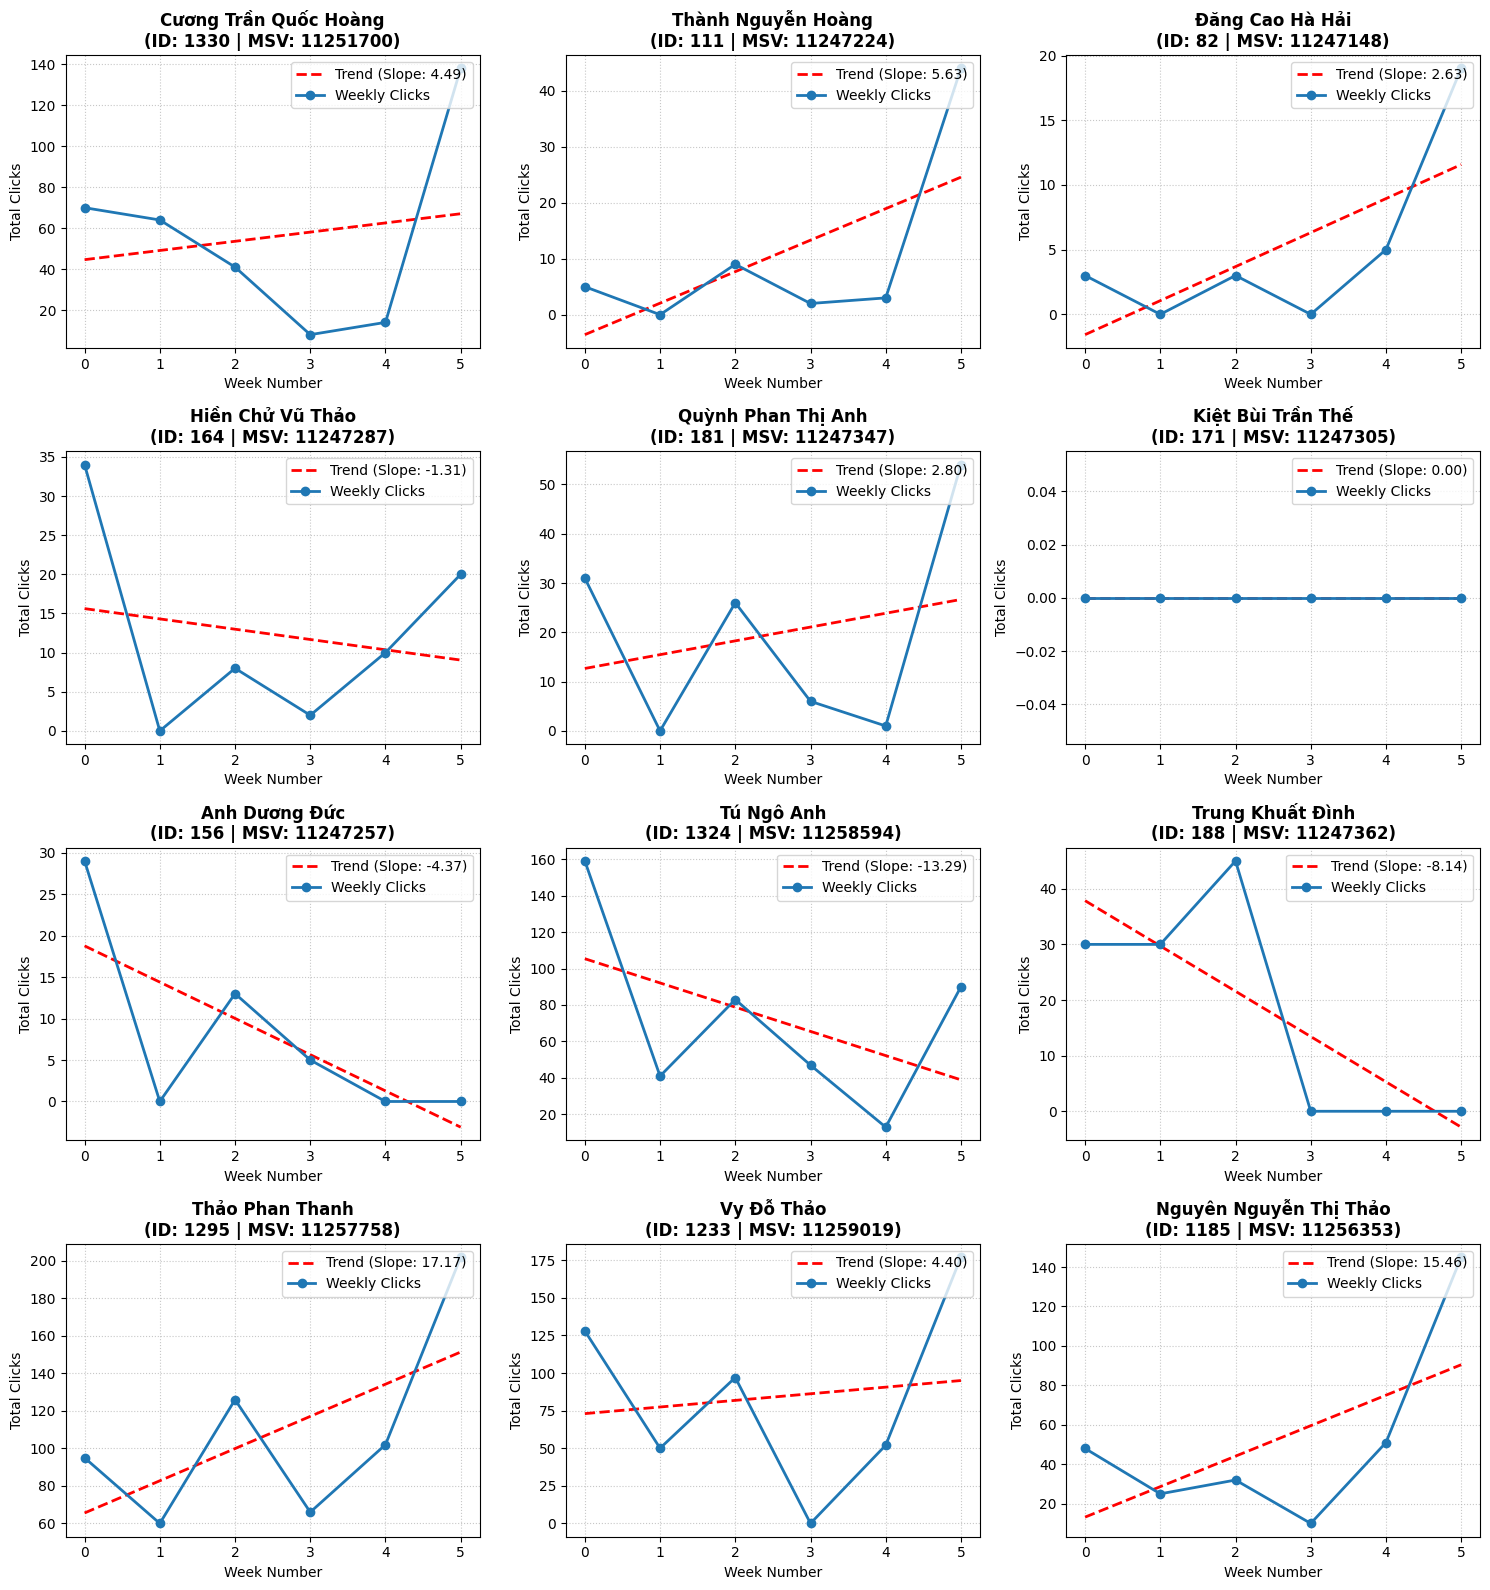

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# --- CONFIGURATION ---
# The list of users you requested (You can input as few or as many as you want!)
target_users = [1330, 111, 82, 164, 181, 171, 156, 1324, 188, 1295, 1233, 1185]
# ---------------------

# 1. Load data
metadata = pd.read_csv('user_course_metadata.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')
clicks_data['click_time'] = pd.to_datetime(clicks_data['local_datetime'])

# 2. Get user metadata (names and MSV extraction)
user_info = metadata[metadata['user_id'].isin(target_users)].copy()
user_info['msv'] = user_info['email'].astype(str).str.split('@').str[0]

# 3. Define the dynamic windows based on MSV cohort and weeks_to_count
end_date_1124 = pd.to_datetime('2025-12-13')
start_date_1124 = end_date_1124 - pd.Timedelta(weeks=weeks_to_count)

end_date_1125 = pd.to_datetime('2026-01-16')
start_date_1125 = end_date_1125 - pd.Timedelta(weeks=weeks_to_count)

# 4. Set up a DYNAMIC matplotlib grid
num_users = len(target_users)
cols = 3  # Let's default to 3 columns, but you can change this
rows = math.ceil(num_users / cols) # Automatically calculates required rows

# Adjust figsize dynamically based on rows and columns
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))

# Ensure axes is a 1D array even if there is only 1 subplot or a single row/column
if num_users == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

# 5. Loop through each user to plot their data
for idx, user_id in enumerate(target_users):
    ax = axes[idx]

    # Check if the user exists in metadata
    user_row = user_info[user_info['user_id'] == user_id]
    if user_row.empty:
        ax.set_title(f"User ID: {user_id} (Not Found)")
        ax.axis('off')
        continue

    msv = str(user_row.iloc[0]['msv'])
    name = user_row.iloc[0]['full_name']

    # Check MSV prefix to determine which date window applies
    if msv.startswith('1124'):
        start_date, end_date = start_date_1124, end_date_1124
    elif msv.startswith('1125'):
        start_date, end_date = start_date_1125, end_date_1125
    else:
        # Fallback if a user belongs to a different cohort
        start_date, end_date = start_date_1124, end_date_1124

    # Filter clicks specifically for this user within their respective timeframe
    user_clicks = clicks_data[(clicks_data['userid'] == user_id) &
                              (clicks_data['click_time'] >= start_date) &
                              (clicks_data['click_time'] < end_date)].copy()

    # Group clicks by week
    user_clicks['week_number'] = (user_clicks['click_time'] - start_date).dt.days // 7
    weekly_counts = user_clicks.groupby('week_number').size().reset_index(name='click_count')

    # Critical step: Ensure all active weeks are represented, filling missing active weeks with 0
    all_weeks = pd.DataFrame({'week_number': range(weeks_to_count)})
    full_weekly = pd.merge(all_weeks, weekly_counts, on='week_number', how='left').fillna(0)

    x = full_weekly['week_number'].values
    y = full_weekly['click_count'].values

    # Calculate Linear Regression (Trendline Equation: y = mx + b)
    # Ensure there's enough data to draw a trendline
    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        trendline = slope * x + intercept
        ax.plot(x, trendline, color='red', linestyle='--', linewidth=2, label=f'Trend (Slope: {slope:.2f})')

    # 6. Build the actual visualizations for the subplot
    ax.plot(x, y, marker='o', linestyle='-', color='tab:blue', linewidth=2, label='Weekly Clicks')

    # Formatting the subplot
    ax.set_title(f"{name}\n(ID: {user_id} | MSV: {msv})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Week Number", fontsize=10)
    ax.set_ylabel("Total Clicks", fontsize=10)
    ax.set_xticks(range(weeks_to_count)) # Dynamically matches the exact number of weeks
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.7)

# 7. Clean up empty subplots (e.g. if you pass 8 users, a 3x3 grid has 1 empty square to hide)
for idx in range(num_users, len(axes)):
    fig.delaxes(axes[idx])

# Adjust spacing so labels don't overlap and export
plt.tight_layout()
plt.savefig('dynamic_user_engagement_plots.png', dpi=300)

# Longest Vanishing

In [ ]:
import pandas as pd

# Load datasets
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')

# Ensure datetime format and extract just the date to calculate daily gaps
clicks_data['click_time'] = pd.to_datetime(clicks_data['local_datetime'])
clicks_data['date'] = clicks_data['click_time'].dt.date

# Define exact Start and End boundaries dynamically based on weeks_to_count
# 1124: weeks ending right before 13/12
boundary_1124 = pd.to_datetime('2025-12-13')
start_1124 = (boundary_1124 - pd.Timedelta(weeks=weeks_to_count)).date()
end_1124 = (boundary_1124 - pd.Timedelta(days=1)).date()  # Inclusive end date (12/12)

# 1125: weeks ending right before 16/01
boundary_1125 = pd.to_datetime('2026-01-16')
start_1125 = (boundary_1125 - pd.Timedelta(weeks=weeks_to_count)).date()
end_1125 = (boundary_1125 - pd.Timedelta(days=1)).date()  # Inclusive end date (15/01)

def calculate_max_inactivity(user_row, user_clicks):
    msv = str(user_row['msv'])

    # Check MSV prefix to determine which date window applies
    if msv.startswith('1124'):
        start_date, end_date = start_1124, end_1124
    elif msv.startswith('1125'):
        start_date, end_date = start_1125, end_1125
    else:
        start_date, end_date = start_1124, end_1124

    # Filter clicks strictly within their dynamic window
    valid_clicks = user_clicks[(user_clicks['date'] >= start_date) &
                               (user_clicks['date'] <= end_date)]

    # If the user has completely 0 clicks, their gap is the full window length (in days)
    if valid_clicks.empty:
        return (end_date - start_date).days + 1

    # Get a sorted list of unique days the student actually showed up
    active_dates = sorted(valid_clicks['date'].unique())

    gaps = []

    # 1. Gap from the start of the timeframe to their very first click
    gaps.append((active_dates[0] - start_date).days)

    # 2. Gaps between consecutive active days
    for i in range(1, len(active_dates)):
        # Subtract 1 because two adjacent days (e.g., 2nd and 3rd) have a gap of 0 days between them
        gap = (active_dates[i] - active_dates[i-1]).days - 1
        gaps.append(gap)

    # 3. Gap from their last click to the final day of the timeframe
    gaps.append((end_date - active_dates[-1]).days)

    # Return the absolute highest number of days they were missing
    return max(gaps) if gaps else 0

# Apply the function to all users
results = []
for _, row in unique_users.iterrows():
    user_id = row['user_id']
    user_clicks = clicks_data[clicks_data['userid'] == user_id]
    max_gap = calculate_max_inactivity(row, user_clicks)

    results.append({
        'user_id': user_id,
        'full_name': row['full_name'],
        'msv': row['msv'],
        'long_inactivity_gap': max_gap
    })

# Convert to DataFrame, sort by longest gap, and save!
gap_df = pd.DataFrame(results).sort_values(by='long_inactivity_gap', ascending=False)

# Make the output file name dynamic too, so you don't accidentally overwrite files when testing different week lengths
output_filename = f'{output_folder}/long_inactivity_gaps_{weeks_to_count}w.csv'
gap_df.to_csv(output_filename, index=False, encoding='utf-8')

# Optional: Print out a quick summary
print(f"Successfully calculated inactivity gaps using a {weeks_to_count}-week window.")
print(f"Results saved to: {output_filename}")

Successfully calculated inactivity gaps using a 6-week window.
Results saved to: processed3/long_inactivity_gaps_6w.csv


# Weekly click std

In [ ]:
import pandas as pd

# 1. Load data
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')
clicks_data['click_time'] = pd.to_datetime(clicks_data['local_datetime'])

# 2. Define the specific target windows dynamically
boundary_1124 = pd.to_datetime('2025-12-13')
start_1124 = boundary_1124 - pd.Timedelta(weeks=weeks_to_count)
end_1124 = boundary_1124

boundary_1125 = pd.to_datetime('2026-01-16')
start_1125 = boundary_1125 - pd.Timedelta(weeks=weeks_to_count)
end_1125 = boundary_1125

# 3. Merge users with their clicks
merged_data = pd.merge(unique_users, clicks_data, left_on='user_id', right_on='userid', how='inner')

# 4. Filter for 1124 students
mask_1124 = (
    merged_data['msv'].astype(str).str.startswith('1124') &
    (merged_data['click_time'] >= start_1124) &
    (merged_data['click_time'] < end_1124)
)
data_1124 = merged_data[mask_1124].copy()
data_1124['week_number'] = (data_1124['click_time'] - start_1124).dt.days // 7

# 5. Filter for 1125 students
mask_1125 = (
    merged_data['msv'].astype(str).str.startswith('1125') &
    (merged_data['click_time'] >= start_1125) &
    (merged_data['click_time'] < end_1125)
)
data_1125 = merged_data[mask_1125].copy()
data_1125['week_number'] = (data_1125['click_time'] - start_1125).dt.days // 7

# 6. Combine the valid data
valid_clicks = pd.concat([data_1124, data_1125])

# 7. Group by user and week to get the raw click counts per week
weekly_counts = valid_clicks.groupby(['user_id', 'full_name', 'msv', 'week_number']).size().reset_index(name='click_count')

# 8. --- CRITICAL ENHANCEMENT: Fill missing weeks with 0 ---
# If a student doesn't study at all for a week, it must count as 0 to accurately calculate the Standard Deviation
users_list = unique_users[['user_id', 'full_name', 'msv']].drop_duplicates()
weeks = pd.DataFrame({'week_number': range(weeks_to_count)})
all_combinations = users_list.merge(weeks, how='cross')

full_weekly_data = pd.merge(all_combinations, weekly_counts, on=['user_id', 'full_name', 'msv', 'week_number'], how='left')
full_weekly_data['click_count'] = full_weekly_data['click_count'].fillna(0)

# 9. Calculate the Standard Deviation of weekly clicks
# Using pandas .std() which defaults to sample standard deviation
user_std = full_weekly_data.groupby(['user_id', 'full_name', 'msv'])['click_count'].std().reset_index(name='weekly_click_std')

# Sort so the highest standard deviation (most erratic/cramming behavior) is at the top
user_std = user_std.sort_values(by='weekly_click_std', ascending=False)

# 10. Save the results
output_file = f'{output_folder}/weekly_click_std.csv'
user_std.to_csv(output_file, index=False, encoding='utf-8')

# Late submission ratio

In [ ]:
import pandas as pd

# 1. Load the new, correct data file and our unique users list
submission_data = pd.read_csv('late_submissions_data.csv', encoding='utf-8')
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')

# 2. Aggregate the submissions across all courses for each user
# Since a user might be in multiple courses, we sum their stats up
user_submissions = submission_data.groupby('userid').agg(
    total_submitted=('total_submitted', 'sum'),
    total_late=('total_late', 'sum')
).reset_index()

# 3. Calculate the late ratio
# We use a lambda function to prevent 'division by zero' errors if a student submitted 0 tasks total
user_submissions['late_ratio'] = user_submissions.apply(
    lambda row: row['total_late'] / row['total_submitted'] if row['total_submitted'] > 0 else 0.0,
    axis=1
)
user_submissions['late_ratio'] = user_submissions['late_ratio'].round(4) # Clean 4 decimal format

# 4. Merge with the user metadata (full_name, msv)
final_result = pd.merge(unique_users, user_submissions, left_on='user_id', right_on='userid', how='inner')
final_result = final_result.drop(columns=['userid']) # Drop duplicate ID column

# 5. Sort by highest ratio first, then by the highest number of total submitted tasks
final_result = final_result.sort_values(by=['late_ratio', 'total_submitted'], ascending=[False, False])

# 6. Save the accurate results to a new CSV
output_file = f'{output_folder}/user_submission_ratios.csv'
final_result.to_csv(output_file, index=False, encoding='utf-8')

# Quiz Retry Ratio

In [ ]:
import pandas as pd

# 1. Load the data
quiz_data = pd.read_csv('quiz_retry_data.csv', encoding='utf-8')
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')

# 2. Aggregate the quiz data across all courses for each user
user_quizzes = quiz_data.groupby('userid').agg(
    total_attempts=('total_attempts', 'sum'),
    total_unique_quizzes=('unique_quizzes', 'sum')
).reset_index()

# 3. Calculate the quiz_retry_ratio
# Using a lambda function to safely handle students who haven't taken any quizzes (returns 0.0)
user_quizzes['quiz_retry_ratio'] = user_quizzes.apply(
    lambda row: (row['total_attempts'] - row['total_unique_quizzes']) / row['total_unique_quizzes'] if row['total_unique_quizzes'] > 0 else 0.0,
    axis=1
).round(2)

# 4. Merge with the user metadata (full_name, msv)
final_result = pd.merge(unique_users, user_quizzes, left_on='user_id', right_on='userid', how='inner')
final_result = final_result.drop(columns=['userid']) # Drop duplicate ID column

# 5. Sort by highest ratio first
final_result = final_result.sort_values(by=['quiz_retry_ratio', 'total_attempts'], ascending=[False, False])

# 6. Save the results
output_file = f'{output_folder}/user_quiz_retry_ratio.csv'
final_result.to_csv(output_file, index=False, encoding='utf-8')

# Late night ratio by total active day


In [ ]:
import pandas as pd


# 1. Load the data
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')

# 2. Convert raw timestamp to datetime and extract the hour and exact date
clicks_data['local_datetime'] = pd.to_datetime(clicks_data['local_datetime'])
clicks_data['hour'] = clicks_data['local_datetime'].dt.hour
clicks_data['date'] = clicks_data['local_datetime'].dt.date

# 3. Define the specific target windows dynamically based on weeks_to_count
boundary_1124 = pd.to_datetime('2025-12-13')
start_1124 = boundary_1124 - pd.Timedelta(weeks=weeks_to_count)

boundary_1125 = pd.to_datetime('2026-01-16')
start_1125 = boundary_1125 - pd.Timedelta(weeks=weeks_to_count)

# 4. Merge users with their clicks
merged_data = pd.merge(unique_users, clicks_data, left_on='user_id', right_on='userid', how='inner')

# 5. Filter for 1124 students within their window
mask_1124 = (
    merged_data['msv'].astype(str).str.startswith('1124') &
    (merged_data['local_datetime'] >= start_1124) &
    (merged_data['local_datetime'] < boundary_1124)
)
data_1124 = merged_data[mask_1124].copy()

# 6. Filter for 1125 students within their window
mask_1125 = (
    merged_data['msv'].astype(str).str.startswith('1125') &
    (merged_data['local_datetime'] >= start_1125) &
    (merged_data['local_datetime'] < boundary_1125)
)
data_1125 = merged_data[mask_1125].copy()

# 7. Combine the valid data
valid_clicks = pd.concat([data_1124, data_1125])

# 8. Identify late-night clicks (22:00 to 03:59 AM)
valid_clicks['is_late_night'] = valid_clicks['hour'].apply(lambda x: 1 if x >= 22 or x < 4 else 0)

# 9. Aggregate by user and DATE first to find days with late-night activity
daily_summary = valid_clicks.groupby(['userid', 'date']).agg(
    daily_total_clicks=('userid', 'count'),
    daily_late_night_clicks=('is_late_night', 'sum')
).reset_index()

# Flag the day as a "late night day" if there was at least 1 late-night click that day
daily_summary['is_late_night_day'] = daily_summary['daily_late_night_clicks'].apply(lambda x: 1 if x > 0 else 0)

# 10. Aggregate by user to calculate the DAY-based ratio
user_days = daily_summary.groupby('userid').agg(
    total_active_days=('date', 'count'),
    late_night_active_days=('is_late_night_day', 'sum')
).reset_index()

# Calculate the ratio (Late-night active days / Total active days)
user_days['late_night_day_ratio'] = (user_days['late_night_active_days'] / user_days['total_active_days']).fillna(0).round(4)

# 11. Merge back with the FULL unique_users list
final_result = pd.merge(unique_users, user_days, left_on='user_id', right_on='userid', how='left')

# Handle missing values (users who didn't log in at all)
final_result['total_active_days'] = final_result['total_active_days'].fillna(0).astype(int)
final_result['late_night_active_days'] = final_result['late_night_active_days'].fillna(0).astype(int)
final_result['late_night_day_ratio'] = final_result['late_night_day_ratio'].fillna(0)

if 'userid' in final_result.columns:
    final_result = final_result.drop(columns=['userid'])

# 12. Sort by highest ratio first, then by the highest total active days
final_result = final_result.sort_values(by=['late_night_day_ratio', 'total_active_days'], ascending=[False, False])

# 13. Output to CSV dynamically
output_filename = f'{output_folder}/user_late_night_day_ratio_{weeks_to_count}w_by_active_days.csv'
final_result.to_csv(output_filename, index=False, encoding='utf-8')

# Late night ratio by 7 days (a week)

In [ ]:
import pandas as pd


# 1. Load the data
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')

# 2. Convert raw timestamp to datetime and extract the hour and exact date
clicks_data['local_datetime'] = pd.to_datetime(clicks_data['local_datetime'])
clicks_data['hour'] = clicks_data['local_datetime'].dt.hour
clicks_data['date'] = clicks_data['local_datetime'].dt.date

# 3. Define the specific target windows dynamically based on weeks_to_count
boundary_1124 = pd.to_datetime('2025-12-13')
start_1124 = boundary_1124 - pd.Timedelta(weeks=weeks_to_count)

boundary_1125 = pd.to_datetime('2026-01-16')
start_1125 = boundary_1125 - pd.Timedelta(weeks=weeks_to_count)

# 4. Merge users with their clicks
merged_data = pd.merge(unique_users, clicks_data, left_on='user_id', right_on='userid', how='inner')

# 5. Filter for 1124 students within their window
mask_1124 = (
    merged_data['msv'].astype(str).str.startswith('1124') &
    (merged_data['local_datetime'] >= start_1124) &
    (merged_data['local_datetime'] < boundary_1124)
)
data_1124 = merged_data[mask_1124].copy()

# 6. Filter for 1125 students within their window
mask_1125 = (
    merged_data['msv'].astype(str).str.startswith('1125') &
    (merged_data['local_datetime'] >= start_1125) &
    (merged_data['local_datetime'] < boundary_1125)
)
data_1125 = merged_data[mask_1125].copy()

# 7. Combine the valid data
valid_clicks = pd.concat([data_1124, data_1125])

# 8. Identify late-night clicks (22:00 to 03:59 AM)
valid_clicks['is_late_night'] = valid_clicks['hour'].apply(lambda x: 1 if x >= 22 or x < 4 else 0)

# 9. Aggregate by user and DATE first to find days with late-night activity
daily_summary = valid_clicks.groupby(['userid', 'date']).agg(
    daily_total_clicks=('userid', 'count'),
    daily_late_night_clicks=('is_late_night', 'sum')
).reset_index()

# Flag the day as a "late night day" if there was at least 1 late-night click that day
daily_summary['is_late_night_day'] = daily_summary['daily_late_night_clicks'].apply(lambda x: 1 if x > 0 else 0)

# 10. Aggregate by user to calculate the DAY-based ratio
user_days = daily_summary.groupby('userid').agg(
    total_active_days=('date', 'count'),
    late_night_active_days=('is_late_night_day', 'sum')
).reset_index()

# Calculate the ratio (Late-night active days / Total active days)
user_days['late_night_day_ratio'] = (user_days['late_night_active_days'] / (weeks_to_count*7)).fillna(0).round(4)

# 11. Merge back with the FULL unique_users list
final_result = pd.merge(unique_users, user_days, left_on='user_id', right_on='userid', how='left')

# Handle missing values (users who didn't log in at all)
final_result['total_active_days'] = final_result['total_active_days'].fillna(0).astype(int)
final_result['late_night_active_days'] = final_result['late_night_active_days'].fillna(0).astype(int)
final_result['late_night_day_ratio'] = final_result['late_night_day_ratio'].fillna(0)

if 'userid' in final_result.columns:
    final_result = final_result.drop(columns=['userid'])

# 12. Sort by highest ratio first, then by the highest total active days
final_result = final_result.sort_values(by=['late_night_day_ratio', 'total_active_days'], ascending=[False, False])

# 13. Output to CSV dynamically
output_filename = f'{output_folder}/user_late_night_day_ratio_{weeks_to_count}w_by_7days.csv'
final_result.to_csv(output_filename, index=False, encoding='utf-8')

# Circadian

In [ ]:
import pandas as pd
import numpy as np

# 1. Load data
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')

# 2. Extract the hour from local_datetime
clicks_data['local_datetime'] = pd.to_datetime(clicks_data['local_datetime'])
clicks_data['hour'] = clicks_data['local_datetime'].dt.hour

# Filter clicks down to our unique users
target_ids = unique_users['user_id'].tolist()
user_clicks = clicks_data[clicks_data['userid'].isin(target_ids)].copy()

# 3. Define the Time Ranges (Bins) based on your explicit columns
def categorize_time(hour):
    if 5 <= hour < 11:
        return 'morning_clicks'
    elif 11 <= hour < 19:
        return 'noon_clicks'
    elif 19 <= hour < 23:
        return 'night_clicks'
    else:  # Late Night (23-5am)
        return 'late_night_clicks'

user_clicks['time_period'] = user_clicks['hour'].apply(categorize_time)

# 4. Count clicks in each time period per user using a pivot table
pivot_clicks = user_clicks.pivot_table(
    index='userid',
    columns='time_period',
    aggfunc='size',
    fill_value=0
).reset_index()

# 5. Calculate Total Clicks and Ratios
pivot_clicks['total_clicks'] = pivot_clicks[['morning_clicks', 'noon_clicks', 'night_clicks', 'late_night_clicks']].sum(axis=1)

pivot_clicks['ratio_morning'] = (pivot_clicks['morning_clicks'] / pivot_clicks['total_clicks']).fillna(0).round(4)
pivot_clicks['ratio_noon'] = (pivot_clicks['noon_clicks'] / pivot_clicks['total_clicks']).fillna(0).round(4)
pivot_clicks['ratio_night'] = (pivot_clicks['night_clicks'] / pivot_clicks['total_clicks']).fillna(0).round(4)
pivot_clicks['ratio_late_night'] = (pivot_clicks['late_night_clicks'] / pivot_clicks['total_clicks']).fillna(0).round(4)

# 6. Calculate Circadian Entropy (Sự hỗn loạn giờ giấc)
# Using Shannon Entropy: H = -sum(p * log2(p)). Higher entropy = more chaotic/random schedule.
def calculate_entropy(row):
    probs = [row['ratio_morning'], row['ratio_noon'], row['ratio_night'], row['ratio_late_night']]
    # Filter out 0s because log(0) is mathematically undefined
    probs = [p for p in probs if p > 0]
    if not probs:
        return 0.0
    return -sum(p * np.log2(p) for p in probs)

pivot_clicks['circadian_entropy'] = pivot_clicks.apply(calculate_entropy, axis=1).round(4)

# Determine the user's single most active period
def get_most_active(row):
    periods = {
        'Morning (5-11)': row['ratio_morning'],
        'Noon (11-19)': row['ratio_noon'],
        'Night (19-23)': row['ratio_night'],
        'Late Night (23-5)': row['ratio_late_night']
    }
    return max(periods, key=periods.get) if row['total_clicks'] > 0 else 'None'

pivot_clicks['most_active_period'] = pivot_clicks.apply(get_most_active, axis=1)

# 7. Merge with Metadata to get names and MSV
final_result = pd.merge(unique_users, pivot_clicks, left_on='user_id', right_on='userid', how='left')
final_result = final_result.fillna(0) # Fill NaNs for users with 0 total clicks
final_result = final_result.drop(columns=['userid'], errors='ignore')

# 8. Sort by highest circadian entropy first (highest chaos)
final_result = final_result.sort_values(by=['circadian_entropy', 'total_clicks'], ascending=[False, False])

# Output to CSV
final_result.to_csv(f'{output_folder}/user_circadian_entropy.csv', index=False, encoding='utf-8')

# Burst days

In [ ]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
burst_multiplier = 2 # Threshold: "cao gấp đôi mức trung bình"
# ---------------------

# 1. Load data
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')

# 2. Convert to datetime and extract the exact date
clicks_data['local_datetime'] = pd.to_datetime(clicks_data['local_datetime'])
clicks_data['date'] = clicks_data['local_datetime'].dt.date

# 3. Define the exact 6-week windows dynamically
boundary_1124 = pd.to_datetime('2025-12-13')
start_1124 = (boundary_1124 - pd.Timedelta(weeks=weeks_to_count)).date()
end_1124 = boundary_1124.date()

boundary_1125 = pd.to_datetime('2026-01-16')
start_1125 = (boundary_1125 - pd.Timedelta(weeks=weeks_to_count)).date()
end_1125 = boundary_1125.date()

# 4. Merge users with clicks to begin filtering
merged_data = pd.merge(unique_users, clicks_data, left_on='user_id', right_on='userid', how='inner')

# 5. Filter for 1124 & 1125 students (6-week window)
mask_1124 = (
    merged_data['msv'].astype(str).str.startswith('1124') &
    (merged_data['date'] >= start_1124) &
    (merged_data['date'] < end_1124)
)
data_1124 = merged_data[mask_1124].copy()

mask_1125 = (
    merged_data['msv'].astype(str).str.startswith('1125') &
    (merged_data['date'] >= start_1125) &
    (merged_data['date'] < end_1125)
)
data_1125 = merged_data[mask_1125].copy()

valid_clicks = pd.concat([data_1124, data_1125])

# 6. Group by User and Date to get DAILY clicks
daily_counts = valid_clicks.groupby(['userid', 'date']).size().reset_index(name='daily_clicks')

# 7. Define the Burst Calculation Logic
def calculate_burst_metrics(group):
    # This group inherently skips dates where daily_clicks = 0
    clicks = group['daily_clicks'].values
    active_days = len(clicks)

    if active_days == 0:
        return pd.Series({
            'active_days_count': 0,
            'avg_daily_clicks': 0.0,
            'std_daily_clicks': 0.0,
            'burst_activity_days': 0
        })

    avg_clicks = np.mean(clicks)
    # Calculate Standard Deviation. If only 1 active day, std is naturally 0.
    std_clicks = np.std(clicks, ddof=1) if active_days > 1 else 0.0

    # Burst days = Count of days where clicks are >= 2 * average
    burst_days = np.sum(clicks >= (burst_multiplier * avg_clicks))

    return pd.Series({
        'active_days_count': active_days,
        'avg_daily_clicks': round(avg_clicks, 2),
        'std_daily_clicks': round(std_clicks, 2),
        'burst_activity_days': int(burst_days)
    })

# 8. Apply the logic to each user
user_bursts = daily_counts.groupby('userid').apply(calculate_burst_metrics).reset_index()

# 9. Merge back with unique users to ensure everyone is included (even 0 activity users)
final_result = pd.merge(unique_users, user_bursts, left_on='user_id', right_on='userid', how='left')

# 10. Clean up missing data (users who never logged in during the 6 weeks)
final_result['active_days_count'] = final_result['active_days_count'].fillna(0).astype(int)
final_result['avg_daily_clicks'] = final_result['avg_daily_clicks'].fillna(0.0)
final_result['std_daily_clicks'] = final_result['std_daily_clicks'].fillna(0.0)
final_result['burst_activity_days'] = final_result['burst_activity_days'].fillna(0).astype(int)
if 'userid' in final_result.columns:
    final_result = final_result.drop(columns=['userid'])

# 11. Sort by highest burst days
final_result = final_result.sort_values(by=['burst_activity_days', 'avg_daily_clicks'], ascending=[False, False])

# 12. Output to CSV dynamically
output_filename = f'{output_folder}/burst_activity_{weeks_to_count}w_{burst_multiplier}x.csv'
final_result.to_csv(output_filename, index=False, encoding='utf-8')

/tmp/ipykernel_45137/3657917430.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_bursts = daily_counts.groupby('userid').apply(calculate_burst_metrics).reset_index()


# Session

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the data
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')
clicks_data = pd.read_csv('all_clicks_history.csv', encoding='utf-8')

# 2. Convert to datetime format
clicks_data['local_datetime'] = pd.to_datetime(clicks_data['local_datetime'])

# 3. Define the dynamic windows based on weeks_to_count
boundary_1124 = pd.to_datetime('2025-12-13')
start_1124 = boundary_1124 - pd.Timedelta(weeks=weeks_to_count)

boundary_1125 = pd.to_datetime('2026-01-16')
start_1125 = boundary_1125 - pd.Timedelta(weeks=weeks_to_count)

# 4. Merge users with clicks to begin filtering
merged_data = pd.merge(unique_users, clicks_data, left_on='user_id', right_on='userid', how='inner')

# 5. Filter for 1124 students (6-week window)
mask_1124 = (
    merged_data['msv'].astype(str).str.startswith('1124') &
    (merged_data['local_datetime'] >= start_1124) &
    (merged_data['local_datetime'] < boundary_1124)
)
data_1124 = merged_data[mask_1124].copy()

# 6. Filter for 1125 students (6-week window)
mask_1125 = (
    merged_data['msv'].astype(str).str.startswith('1125') &
    (merged_data['local_datetime'] >= start_1125) &
    (merged_data['local_datetime'] < boundary_1125)
)
data_1125 = merged_data[mask_1125].copy()

# 7. Combine the valid data and crucially, SORT chronologically for every user
valid_clicks = pd.concat([data_1124, data_1125])
valid_clicks = valid_clicks.sort_values(by=['userid', 'local_datetime'])

# 8. --- THE SESSIONIZATION ENGINE ---
# Calculate the exact time difference between consecutive clicks for every user
valid_clicks['time_diff'] = valid_clicks.groupby('userid')['local_datetime'].diff()

# Set the session killer threshold based on your config
window_td = pd.Timedelta(hours=session_window_hours)

# Identify where a NEW session starts:
# True if: It's their very first click (time_diff is NaT) OR the gap exceeds the window
valid_clicks['is_new_session'] = (valid_clicks['time_diff'] > window_td) | (valid_clicks['time_diff'].isna())

# Use cumulative sum to group consecutive clicks into a distinct Session ID
valid_clicks['session_id'] = valid_clicks.groupby('userid')['is_new_session'].cumsum()

# 9. Calculate the duration of each individual session
# Group by the distinct session IDs to find the exact start and end times
sessions = valid_clicks.groupby(['userid', 'session_id'])['local_datetime'].agg(
    session_start='min',
    session_end='max',
    clicks_in_session='count'
).reset_index()

# Convert the gap between start and end into minutes
sessions['duration_minutes'] = (sessions['session_end'] - sessions['session_start']).dt.total_seconds() / 60.0

# 10. Aggregate to find the specific User averages
user_sessions = sessions.groupby('userid').agg(
    total_sessions=('session_id', 'count'),
    total_clicks_6w=('clicks_in_session', 'sum'),
    avg_session_duration_minutes=('duration_minutes', 'mean'),
    max_session_duration_minutes=('duration_minutes', 'max')
).reset_index()

# Round durations for a cleaner display
user_sessions['avg_session_duration_minutes'] = user_sessions['avg_session_duration_minutes'].round(2)
user_sessions['max_session_duration_minutes'] = user_sessions['max_session_duration_minutes'].round(2)

# 11. Final Merge and Cleanup
# Merge back with unique users list to catch people with 0 activity
final_result = pd.merge(unique_users, user_sessions, left_on='user_id', right_on='userid', how='left')

# Fill missing data with 0s
fill_cols = ['total_sessions', 'total_clicks_6w', 'avg_session_duration_minutes', 'max_session_duration_minutes']
for col in fill_cols:
    final_result[col] = final_result[col].fillna(0)

if 'userid' in final_result.columns:
    final_result = final_result.drop(columns=['userid'])

# Sort by the longest average session duration
final_result = final_result.sort_values(by=['avg_session_duration_minutes', 'total_clicks_6w'], ascending=[False, False])

# 12. Save to CSV dynamically based on the configuration names
output_filename = f'{output_folder}/avg_learning_session_{weeks_to_count}w_{session_window_hours}h.csv'
final_result.to_csv(output_filename, index=False, encoding='utf-8')

# Resource viewed ratio

In [ ]:
import pandas as pd

# 1. Load the data
resource_data = pd.read_csv('resource_view_data.csv', encoding='utf-8')
unique_users = pd.read_csv(f'{output_folder}/unique_users_msv_1124_1125.csv', encoding='utf-8')

# 2. Aggregate the resource data across all courses for each user
user_resources = resource_data.groupby('userid').agg(
    total_viewed=('viewed_resources', 'sum'),
    total_available=('total_resources', 'sum')
).reset_index()

# 3. Calculate the resource view ratio
# We use a lambda function to prevent 'division by zero' errors if a course somehow has 0 resources
user_resources['resource_view_ratio'] = user_resources.apply(
    lambda row: row['total_viewed'] / row['total_available'] if row['total_available'] > 0 else 0.0,
    axis=1
).round(4)

# 4. Merge with the user metadata to append full_name and msv
final_result = pd.merge(unique_users, user_resources, left_on='user_id', right_on='userid', how='inner')
final_result = final_result.drop(columns=['userid']) # Drop duplicate ID column

# 5. Sort by lowest ratio first (to highlight the students who ignore materials)
# And as a tie-breaker, sort by the lowest absolute number of viewed materials
final_result = final_result.sort_values(by=['resource_view_ratio', 'total_viewed'], ascending=[True, True])

# 6. Save the final results to CSV
output_file = f'{output_folder}/user_resource_view_ratio.csv'
final_result.to_csv(output_file, index=False, encoding='utf-8')

# Data plotting

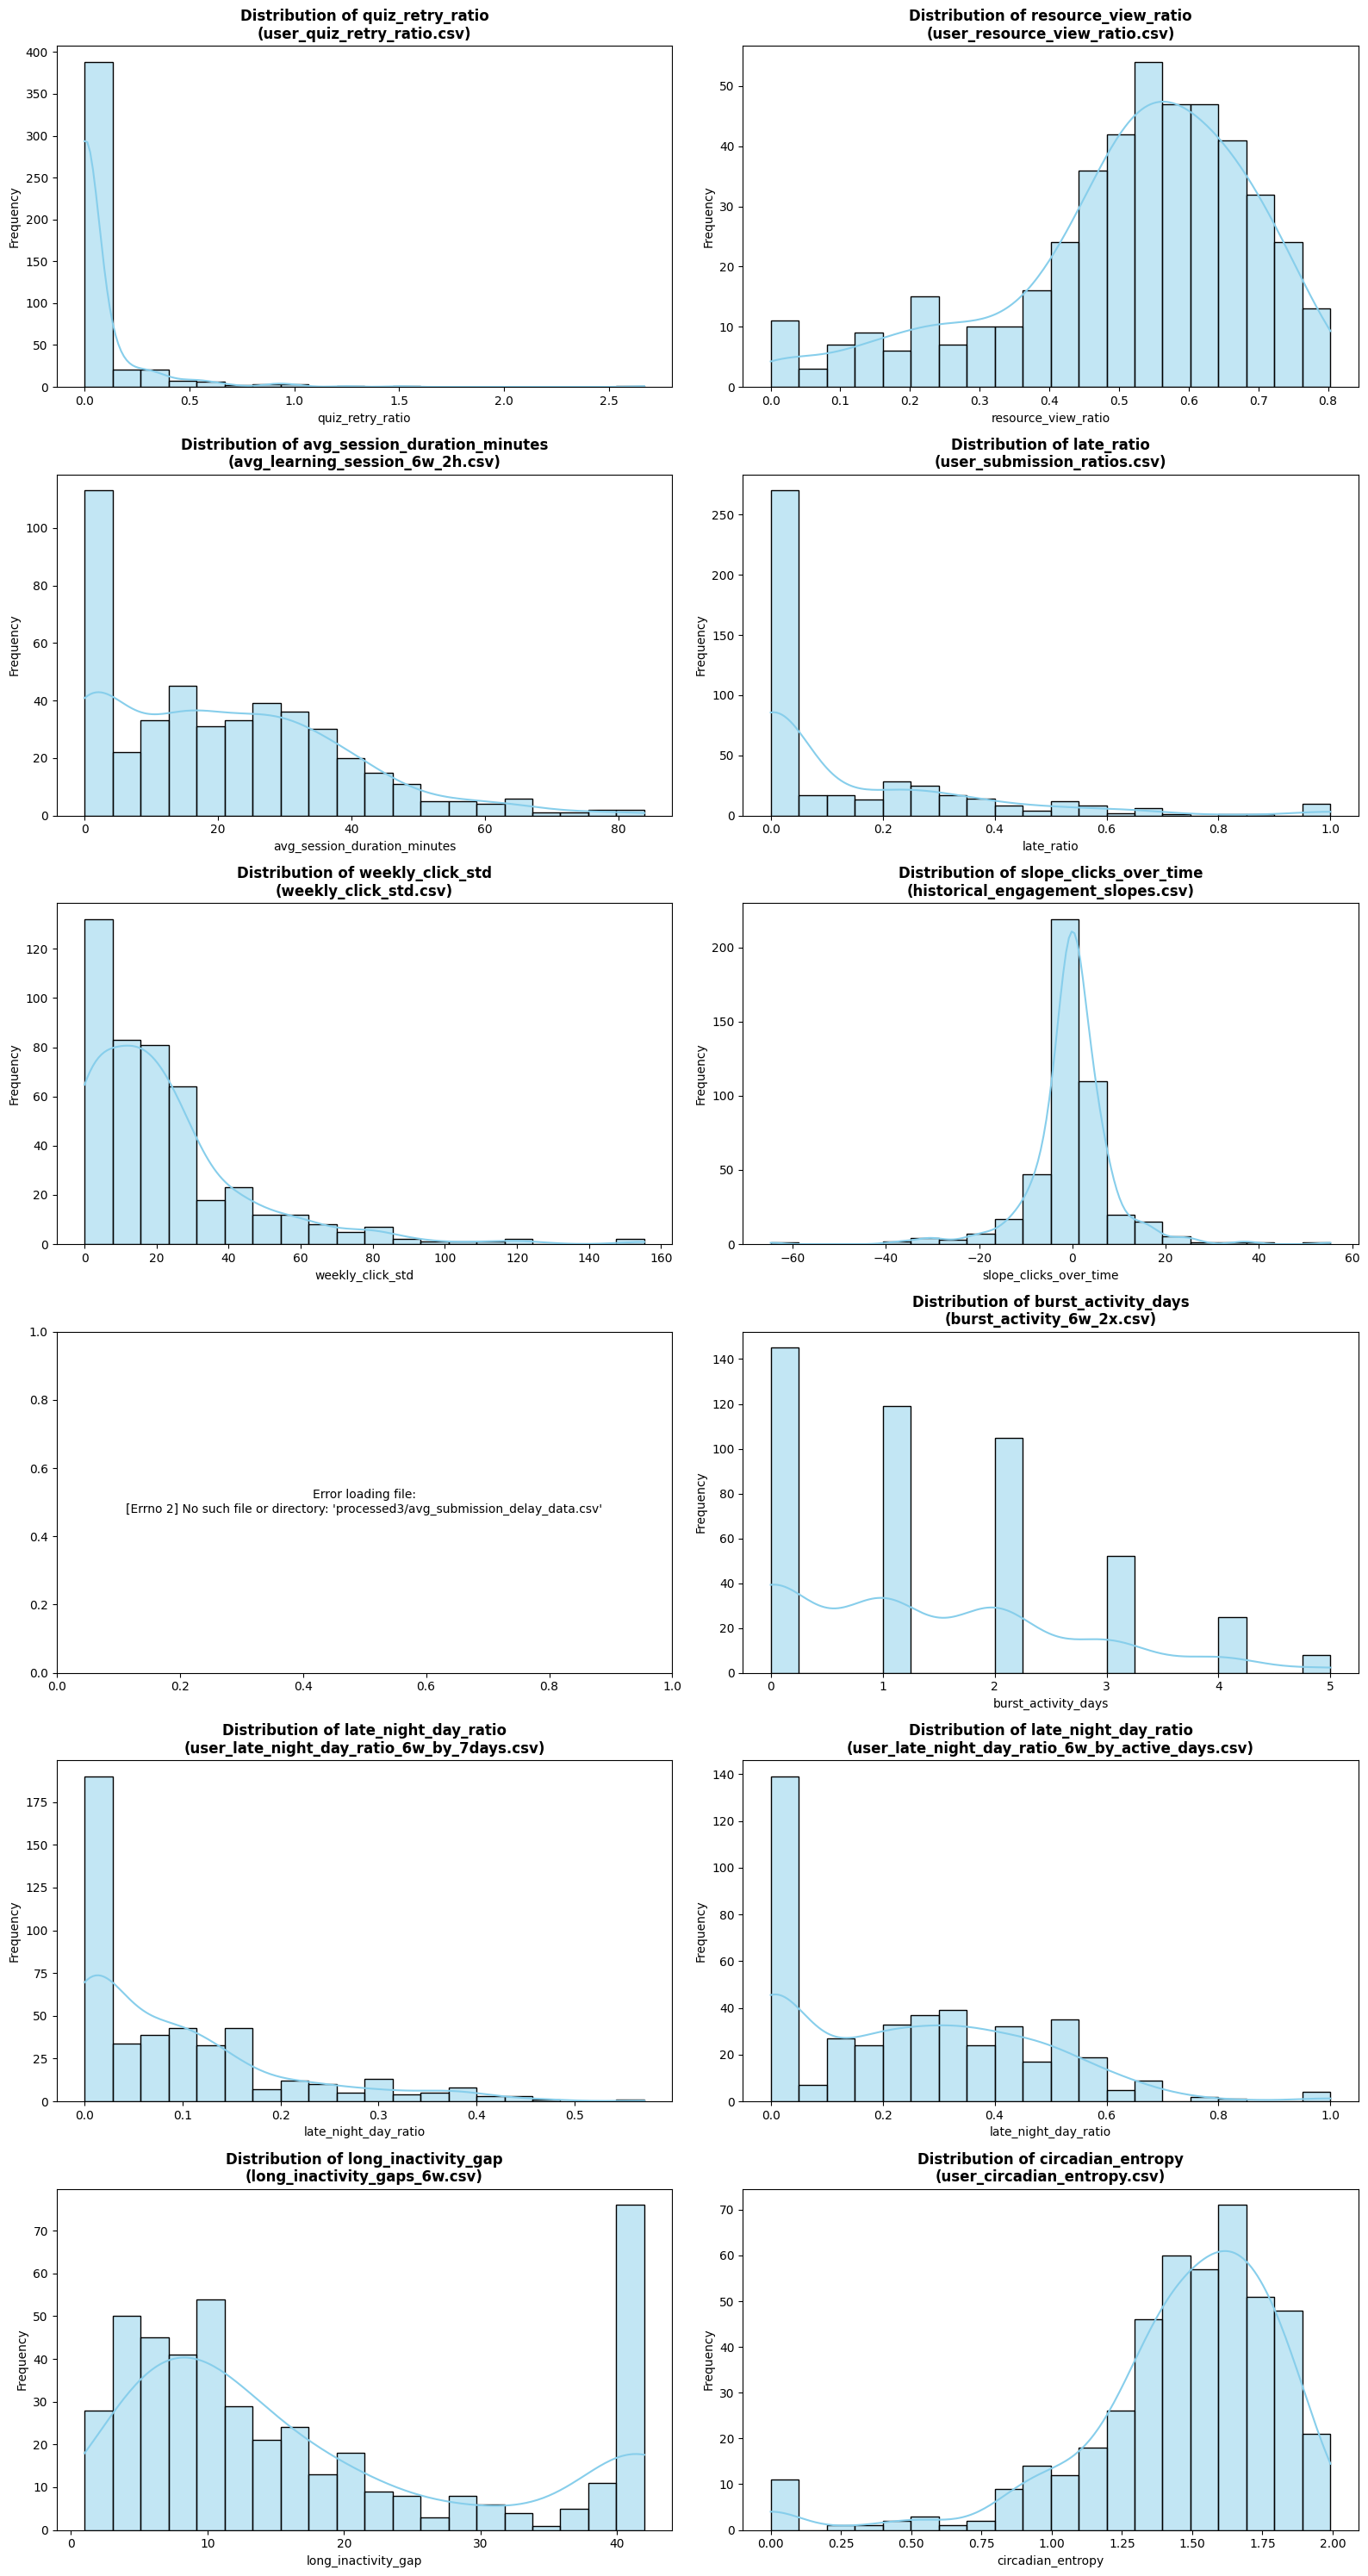

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các file và cột dữ liệu tương ứng cần vẽ
# Fixed the '.csv.csv' typos and updated the correct column names
file_feature_map = {
    'user_quiz_retry_ratio.csv': 'quiz_retry_ratio',
    'user_resource_view_ratio.csv': 'resource_view_ratio',
    f'avg_learning_session_{weeks_to_count}w_2h.csv': 'avg_session_duration_minutes',
    'user_submission_ratios.csv': 'late_ratio',
    'weekly_click_std.csv': 'weekly_click_std',
    'historical_engagement_slopes.csv': 'slope_clicks_over_time',
    'avg_submission_delay_data.csv': 'avg_hours_before_deadline',
    f'burst_activity_{weeks_to_count}w_2x.csv': 'burst_activity_days',
    f'user_late_night_day_ratio_{weeks_to_count}w_by_7days.csv': 'late_night_day_ratio',  # Corrected column name & file name
    f'user_late_night_day_ratio_{weeks_to_count}w_by_active_days.csv': 'late_night_day_ratio', # Assumed corrected column name
    f'long_inactivity_gaps_{weeks_to_count}w.csv': 'long_inactivity_gap',
    'user_circadian_entropy.csv': 'circadian_entropy'
}

# Thiết lập lưới đồ thị
n_files = len(file_feature_map)
cols = 2
rows = (n_files + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, (file_name, feature_col) in enumerate(file_feature_map.items()):
    try:
        # Đọc dữ liệu
        df = pd.read_csv(output_folder + "/" + file_name, encoding='utf-8')

        # Vẽ biểu đồ phân phối
        if feature_col in df.columns:
            sns.histplot(df[feature_col].dropna(), kde=True, ax=axes[i], color='skyblue', bins=20)
            axes[i].set_title(f'Distribution of {feature_col}\n({file_name})', fontsize=12, fontweight='bold')
            axes[i].set_xlabel(feature_col)
            axes[i].set_ylabel('Frequency')
        else:
            axes[i].text(0.5, 0.5, f'Column "{feature_col}"\nnot found in {file_name}', ha='center', va='center')

    except Exception as e:
        axes[i].text(0.5, 0.5, f'Error loading file:\n{str(e)}', ha='center', va='center')

# Xóa các khung đồ thị trống nếu có
for j in range(len(file_feature_map), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
# Thay vì show() thì save lại thành 1 file ảnh tổng quát
plt.savefig('all_features_distributions.png', dpi=300)

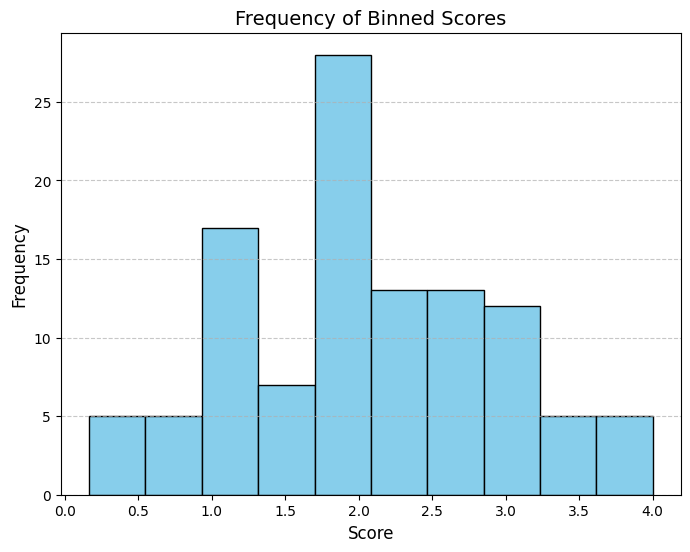

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('final_dataset_with_scores.csv')

# 2. Extract only the 'Score' column (and drop any missing values just in case)
scores = df['Score'].dropna()

# 3. Create a histogram to bin the scores and plot their frequency
# 'bins=10' splits the data into 10 equal-width bins. You can change this number!
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(scores, bins=10, color='skyblue', edgecolor='black')

# 4. Add labels, title, and a grid for better readability
ax.set_title('Frequency of Binned Scores', fontsize=14)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Save the plot as an image (or use plt.show() if running in a Jupyter Notebook)
plt.savefig('score_frequency_plot.png', bbox_inches='tight')

# SPSS Data Preprocess

In [ ]:
import pandas as pd
from functools import reduce

## Combine data

In [ ]:
import pandas as pd
from functools import reduce

output_folder = "processed_data"

# 1. Define all your file names in a list
file_names = [
    'avg_learning_session_6w_2h.csv',
    'burst_activity_6w_2x.csv',
    'historical_engagement_slopes.csv',
    'long_inactivity_gaps_6w.csv',
    'user_circadian_entropy.csv',
    'user_late_night_day_ratio_6w_by_7days.csv',
    'user_late_night_day_ratio_6w_by_active_days.csv',
    'user_quiz_retry_ratio.csv',
    'user_resource_view_ratio.csv',
    'user_submission_ratios.csv',
    'weekly_click_std.csv'
]

# Load all the files into a list of DataFrames
dataframes = [pd.read_csv(f'{output_folder}/{file}') for file in file_names]

# 2. Define the columns you want to remove
cols_to_drop = ['user_id', 'full_name']

# 3. Drop 'user_id' and 'full_name' from every DataFrame in the list
for i in range(len(dataframes)):
    df = dataframes[i]
    dataframes[i] = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 4. Merge ALL DataFrames together using the 'msv' column as the key
# reduce() takes the first two dataframes, merges them, then merges the 3rd, then 4th, etc.
merged_df = reduce(lambda left, right: pd.merge(left, right, on='msv', how='outer'), dataframes)

# 5. Save the combined dataset to a new CSV file
merged_df.to_csv('combined_data_by_msv.csv', index=False)

# Optional: Print the first few rows to verify
print(merged_df.head())
print(f"Total columns in final dataset: {len(merged_df.columns)}")

## Combine scores with lms features

In [ ]:
import pandas as pd

# 1. Load the datasets
beam_df = pd.read_csv('beam_v2.csv')
combined_df = pd.read_csv('combined_data_by_msv.csv')

# 2. Extract only the 'ID' and 'Score' from the beam dataset
# (Using .copy() prevents warnings when modifying a slice of a DataFrame)
beam_subset = beam_df[['ID', 'Score']].copy()

# 3. Rename 'ID' to 'msv' so it perfectly matches the combined dataset
beam_subset = beam_subset.rename(columns={'ID': 'msv'})

# 4. Merge the two datasets
# how='inner' tells Pandas to ONLY keep the rows where the 'msv' exists in BOTH files
final_df = combined_df.merge(beam_subset, on='msv', how='inner')

# 5. Save the matched data with scores to a new file
final_df.to_csv('final_dataset_with_scores.csv', index=False)

# Optional: Print out the counts to verify everything worked
print(f"Original combined_data rows: {len(combined_df)}")
print(f"Original beam_v2 rows: {len(beam_df)}")
print(f"Final matching rows: {len(final_df)}")

## Plotting the score

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('final_dataset_with_scores.csv')

# 2. Extract only the 'Score' column (and drop any missing values just in case)
scores = df['Score'].dropna()

# 3. Create a histogram to bin the scores and plot their frequency
# 'bins=10' splits the data into 10 equal-width bins. You can change this number!
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(scores, bins=10, color='skyblue', edgecolor='black')

# 4. Add labels, title, and a grid for better readability
ax.set_title('Frequency of Binned Scores', fontsize=14)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Save the plot as an image (or use plt.show() if running in a Jupyter Notebook)
plt.savefig('score_frequency_plot.png', bbox_inches='tight')import pandas as pd

def map_student_data(top_students_path, scores_path, output_path):
    # 1. Load the datasets
    # Using 'top_students_beam.xlsx - Sheet1.csv' as the base
    df_top = pd.read_excel(top_students_path)
    
    # Using 'final_dataset_with_scores.csv' as the source for additional data
    df_scores = pd.read_csv(scores_path, encoding="utf-8")

    # 2. Perform the mapping (Merge)
    # We use 'left' join to keep everyone in the top_students file
    # We map on the 'msv' column which exists in both files
    merged_df = pd.merge(df_top, df_scores, on='msv', how='left')

    # 3. Optional: Remove duplicate columns if they exist (like a second 'Score' column)
    # If both files have a 'Score' column, pandas will name them Score_x and Score_y
    if 'Score_y' in merged_df.columns:
        # Keep the one from the final dataset and drop the redundant one
        merged_df['Score'] = merged_df['Score_y']
        merged_df.drop(columns=['Score_x', 'Score_y'], inplace=True)

    # 4. Save the result
    merged_df.to_csv(output_path, index=False, encoding="utf-8")
    print(f"Mapping complete! Result saved to: {output_path}")
    print(f"Total students processed: {len(merged_df)}")

# --- Execution ---
if __name__ == "__main__":
    map_student_data(
        top_students_path='top_students_beam.xlsx',
        scores_path='final_dataset_with_scores.csv',
        output_path='mapped_student_results.csv'
    )